#  과제 문제

## 1. 과제 목표
- Housing 데이터 분석 리포트 작성
- 수업시간에 배운 데이터 분석 기법 활용  

---

## 2. 제출 내용

### 1) 분석 코드
- Python을 활용한 데이터 분석 코드 작성  
- 결측치 제거, 통계 분석 및 시각화, 데이터 스케일링, 회귀 분석, 규제 기법, Grid search, CV 등 활용

### 2) 분석 리포트
- 데이터 설명 (데이터 수, 변수 설명 - 각 변수의 의미, 데이터 타입 등)  
- 분석 코드 설명  
- 분석 결과 및 결론 설명 (통계분석, 선형회귀분석 등 결과 해석)  
- 결론 설명(결과 해석을 바탕으로 본인 의견 작성)  


In [2]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import seaborn as sns


# 한글 폰트 설정
plt.rc('font', family='Malgun Gothic')

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False


# Housing 데이터 정보 및 결측치 제거

# 1-1. 데이터 읽기 확인

In [4]:
# 데이터 불러오기
df = pd.read_csv("data/HousingData.csv")

print("Housing 데이터: ",  df.shape)
df.columns
df.info()
df.describe()

# 14개의 열, 506개의 행
# CRIM	ZN	INDUS  CHAS	 NOX  RM  AGE	DIS	 RAD  TAX	PTRATIO B LSTAT	 MEDV
# MEDV 주택가격 예측 회귀 문제


df['AGE']

Housing 데이터:  (506, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     486 non-null    float64
 1   ZN       486 non-null    float64
 2   INDUS    486 non-null    float64
 3   CHAS     486 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      486 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    486 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


0      65.2
1      78.9
2      61.1
3      45.8
4      54.2
       ... 
501    69.1
502    76.7
503    91.0
504    89.3
505     NaN
Name: AGE, Length: 506, dtype: float64

# 1-2. 데이터 결측치 제거

In [3]:
# 결측치 확인
print(df.isnull().sum())

# 데이터 결측치 제거
df = df.dropna()
print("남은 결측치 수: ", df.isnull().sum())
# 행이 506개에서 394개로 줄어듦
print(df.shape)

CRIM       20
ZN         20
INDUS      20
CHAS       20
NOX         0
RM          0
AGE        20
DIS         0
RAD         0
TAX         0
PTRATIO     0
B           0
LSTAT      20
MEDV        0
dtype: int64
남은 결측치 수:  CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64
(394, 14)


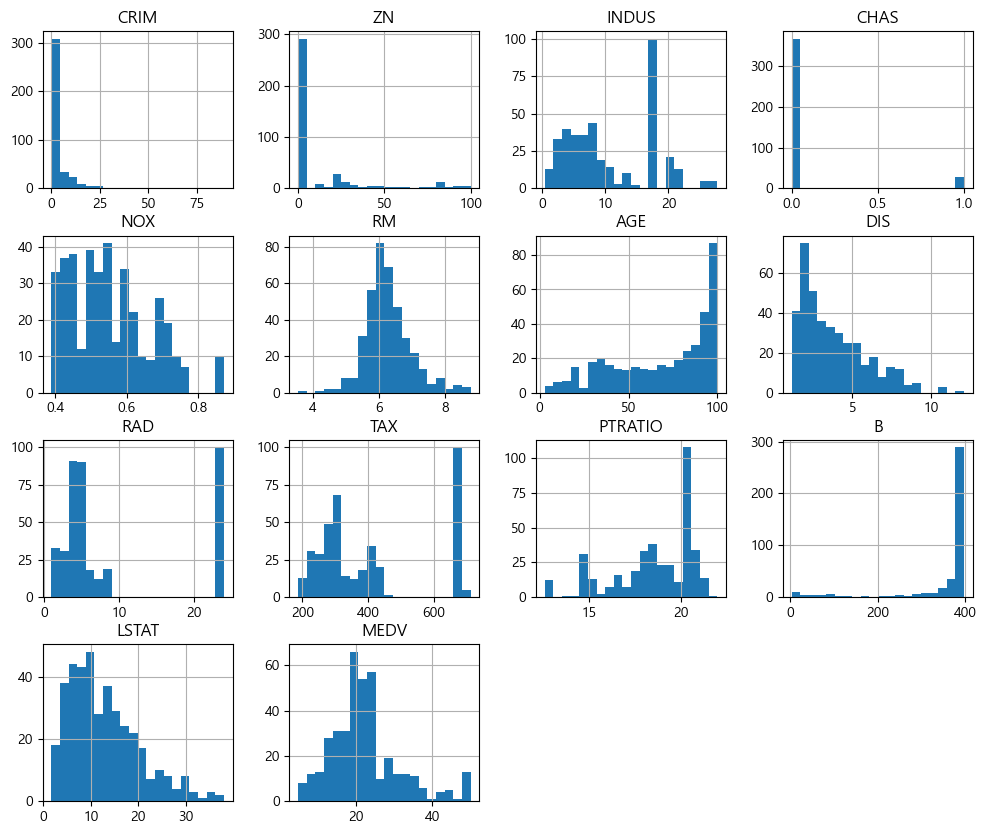

In [4]:
# 데이터의 자료형 변환 작업
df["CHAS"] = df["CHAS"].astype(int)

df.hist(bins=20, figsize=(12,10))
plt.show()

# 1-3. 데이터 셋 Train, Test 분리

In [5]:
# Housing 데이터 셋 Train, Test 분리
x = df.drop(columns = ["MEDV", "AGE", "INDUS"]).astype(float)  # 독립 변수
y = df['MEDV']               # 종속 변수

# 데이터 분리 8:2
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)   

# statsmodels OLS를 위해 상수항 추가
x_train_sm = sm.add_constant(x_train)
x_test_sm = sm.add_constant(x_test)

# 1-4. VIF 계산 다중공산성 확인

In [6]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
# VIF 계산 

def calculate_vif(df):
    vif_data = pd.DataFrame()
    vif_data["Feature"] = df.columns
    vif_data["VIF"] = [
        variance_inflation_factor(df.values, i)
        for i in range(df.shape[1])
    ]
    return vif_data.sort_values(by="VIF", ascending=False)


vif_df = calculate_vif(x_train_sm.drop(columns=["CHAS"], errors="ignore"))
print("VIF 결과")
print(vif_df.head(10))

vif_df = vif_df[vif_df["Feature"] != "const"]

high_vif_features = vif_df[vif_df["VIF"] > 10]["Feature"].tolist()
print(f"VIF > 10인 변수 개수: {len(high_vif_features)}")
print("제거할 변수 목록:", high_vif_features)

VIF 결과
    Feature         VIF
0     const  625.852685
7       TAX    6.542274
6       RAD    6.115752
3       NOX    3.781524
5       DIS    3.485845
10    LSTAT    2.770943
2        ZN    2.182086
4        RM    1.986570
8   PTRATIO    1.779019
1      CRIM    1.673911
VIF > 10인 변수 개수: 0
제거할 변수 목록: []


# 1-5. Housing 데이터 셋 OLS 성능평가

In [7]:
ols_origin = sm.OLS(y_train, x_train_sm).fit()   # OLS 모델 생성
print(ols_origin.summary())                     # 모델 요약 출력

# 성능평가
y_pred = ols_origin.predict(x_test_sm)          # 테스트 데이터에 대한 예측 수행
rmse_ols_origin = np.sqrt(np.mean((y_test - y_pred) ** 2))  # RMSE 계산
r2_ols_origin = 1 - np.sum((y_test - y_pred) ** 2) / np.sum((y_test - np.mean(y_test)) ** 2)  # R² 계산

print(f"RMSE: {rmse_ols_origin:.4f}")
print(f"R²: {r2_ols_origin:.4f}")


                            OLS Regression Results                            
Dep. Variable:                   MEDV   R-squared:                       0.796
Model:                            OLS   Adj. R-squared:                  0.789
Method:                 Least Squares   F-statistic:                     107.5
Date:                Fri, 17 Oct 2025   Prob (F-statistic):           1.16e-97
Time:                        16:03:31   Log-Likelihood:                -891.48
No. Observations:                 315   AIC:                             1807.
Df Residuals:                     303   BIC:                             1852.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         33.9161      5.896      5.753      0.0

# 2. 데이터 스케일링

# 2-1. 데이터 스케일링

In [8]:
# 독립변수, 종속변수 분리
x = df.drop(columns=["MEDV"])
y = df["MEDV"]

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

# CHAS 는 0 / 1 형태의 자료이기 때문에 스케일링에서 제외하고 나중에 추가
x_cols = [c for c in df.columns if c not in ["MEDV", "CHAS"]]

chas_train = x_train["CHAS"].reset_index(drop=True)
chas_test  = x_test["CHAS"].reset_index(drop=True)

# CHAS 제외
x_train = x_train.drop(columns=["CHAS"]).reset_index(drop = True)
x_test = x_test.drop(columns=["CHAS"]).reset_index(drop = True)

y_train = y_train.reset_index(drop=True)
y_test  = y_test.reset_index(drop=True)

In [9]:
# 표준화
x_train_std = (x_train - x_train.mean()) / x_train.std(ddof=0)
x_test_std  = (x_test - x_train.mean()) / x_train.std(ddof=0)
x_train_std.columns = [f"{c}_std" for c in x_cols]
x_test_std.columns  = [f"{c}_std" for c in x_cols] 

In [10]:
# 로그변환
x_train_log = np.log1p(x_train.clip(lower=0))
x_test_log  = np.log1p(x_test.clip(lower=0))
x_train_log.columns = [f"{c}_log" for c in x_cols]
x_test_log.columns  = [f"{c}_log" for c in x_cols]


In [11]:
# 정규화 min-max 스케일링
xmin = x_train.min()
xmax = x_train.max()
x_train_mm = (x_train - xmin) / (xmax - xmin)
x_test_mm  = (x_test - xmin) / (xmax - xmin)

x_train_mm.columns = [f"{c}_mm" for c in x_cols]
x_test_mm.columns  = [f"{c}_mm" for c in x_cols]

In [12]:
# 제곱항
x_train_sq = x_train ** 2
x_test_sq  = x_test ** 2
x_train_sq.columns = [f"{c}_sq" for c in x_cols]
x_test_sq.columns  = [f"{c}_sq" for c in x_cols]

In [13]:
# CHAS 다시 추가
x_train["CHAS"] = chas_train
x_test["CHAS"]  = chas_test
x_cols.append("CHAS")

x_train_all = pd.concat([x_train,x_train_std.reset_index(drop=True),
                         x_train_log.reset_index(drop=True),
                         x_train_mm.reset_index(drop=True),
                         x_train_sq.reset_index(drop=True)], axis=1)

x_test_all = pd.concat([x_test.reset_index(drop=True),
                        x_test_std.reset_index(drop=True),
                        x_test_log.reset_index(drop=True),
                        x_test_mm.reset_index(drop=True),
                        x_test_sq.reset_index(drop=True)], axis=1)

print("원본 특성 수:", len(x_cols))
print("확장된 특성 수:", x_train_all.shape[1])

x_train_sm = sm.add_constant(x_train_all)
x_test_sm  = sm.add_constant(x_test_all, has_constant="add")

print("전체 열 목록")
print(x_train_all.columns.tolist()[:30])

print(" 데이터프레임")
display(x_train_all.head())

원본 특성 수: 13
확장된 특성 수: 61
전체 열 목록
['CRIM', 'ZN', 'INDUS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'CHAS', 'CRIM_std', 'ZN_std', 'INDUS_std', 'NOX_std', 'RM_std', 'AGE_std', 'DIS_std', 'RAD_std', 'TAX_std', 'PTRATIO_std', 'B_std', 'LSTAT_std', 'CRIM_log', 'ZN_log', 'INDUS_log', 'NOX_log', 'RM_log']
 데이터프레임


,CRIM,ZN,INDUS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,...,INDUS_sq,NOX_sq,RM_sq,AGE_sq,DIS_sq,RAD_sq,TAX_sq,PTRATIO_sq,B_sq,LSTAT_sq
0,7.02259,0.0,18.10,0.718,6.006,95.3,1.8746,24,666,20.2,...,327.6100,0.515524,36.072036,9082.09,3.514125,576,443556,408.04,102387.2004,246.4900
1,0.57529,0.0,6.20,0.507,8.337,73.3,3.8384,8,307,17.4,...,38.4400,0.257049,69.505569,5372.89,14.733315,64,94249,302.76,148926.5281,6.1009
2,0.11069,0.0,13.89,0.550,5.951,93.8,2.8893,5,276,16.4,...,192.9321,0.302500,35.414401,8798.44,8.348054,25,76176,268.96,157529.6100,321.1264
3,0.09512,0.0,12.83,0.437,6.286,45.0,4.5026,5,398,18.7,...,164.6089,0.190969,39.513796,2025.00,20.273407,25,158404,349.69,146865.2329,79.9236
4,9.39063,0.0,18.10,0.740,5.627,93.9,1.8172,24,666,20.2,...,327.6100,0.547600,31.663129,8817.21,3.302216,576,443556,408.04,157529.6100,523.4944


# 2-2. 스케일링 후 데이터의 성능 평가

In [14]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression

ols_scaled = sm.OLS(y_train, x_train_sm).fit()
print(ols_scaled.summary())

# 성능 평가
y_pred = ols_scaled.predict(x_test_sm)
rmse_ols_scaled = np.sqrt(np.mean((y_test - y_pred)**2))
r2_ols_scaled = 1 - np.sum((y_test - y_pred)**2) / np.sum((y_test - y_test.mean())**2)

print(f"RMSE: {rmse_ols_scaled:.4f}")
print(f"R²  : {r2_ols_scaled:.4f}")

# OLS 모델의 k-fold 5회 평균 R2 모델 성능평가
cv = KFold(n_splits=5, shuffle=True, random_state=42)
model = LinearRegression()
scores = cross_val_score(model, x_train_all, y_train, cv=cv, scoring="r2")
print("각 fold별 R²:", scores)
print("평균 R²:", np.mean(scores))

                            OLS Regression Results                            
Dep. Variable:                   MEDV   R-squared:                       0.892
Model:                            OLS   Adj. R-squared:                  0.878
Method:                 Least Squares   F-statistic:                     61.94
Date:                Fri, 17 Oct 2025   Prob (F-statistic):          9.22e-113
Time:                        16:03:31   Log-Likelihood:                -791.15
No. Observations:                 315   AIC:                             1658.
Df Residuals:                     277   BIC:                             1801.
Df Model:                          37                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           1.4275      8.293      0.172      

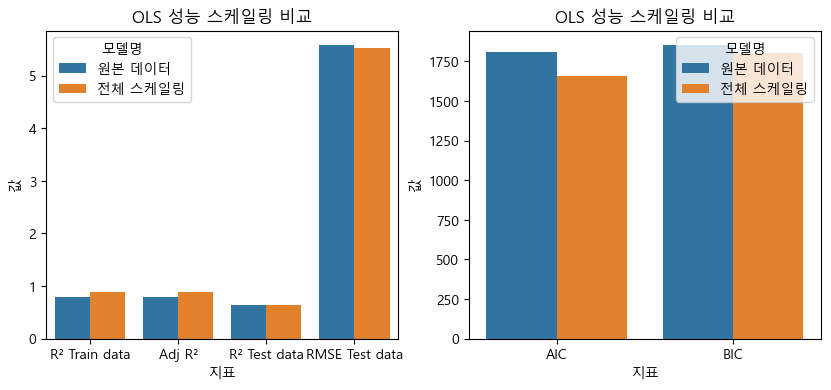

결과 출력
R² Train data     :    0.796 →    0.892 (↑ 향상, dif=0.096)
Adj R²            :    0.789 →    0.878 (↑ 향상, dif=0.089)
R² Test data      :    0.631 →    0.638 (↑ 향상, dif=0.007)
RMSE Test data    :    5.579 →    5.522 (↓ 감소, dif=-0.057)
AIC               : 1806.965 → 1658.305 (↓ 감소, dif=-148.660)
BIC               : 1851.996 → 1800.903 (↓ 감소, dif=-51.093)
- R², Adj R² 값이 높을수록 모델 좋음
- RMSE, AIC, BIC 값이 낮을수록 성능 좋음


In [15]:
results = {
    "모델명": ["원본 데이터", "전체 스케일링"],
    "R² Train data": [ols_origin.rsquared, ols_scaled.rsquared],
    "Adj R²": [ols_origin.rsquared_adj, ols_scaled.rsquared_adj],
    "R² Test data" : [r2_ols_origin, r2_ols_scaled],
    "RMSE Test data": [rmse_ols_origin, rmse_ols_scaled],
    "AIC": [ols_origin.aic, ols_scaled.aic],
    "BIC": [ols_origin.bic, ols_scaled.bic],
}
compare_df = pd.DataFrame(results)
plot1 = compare_df.melt(id_vars="모델명",
                        value_vars=["R² Train data", "Adj R²", "R² Test data", "RMSE Test data"],
                        var_name="지표", value_name="값")

plot2 = compare_df.melt(id_vars="모델명",
                        value_vars=["AIC", "BIC"],
                        var_name="지표", value_name="값")

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.barplot(data=plot1, x="지표", y="값", hue="모델명", ax=axes[0])
axes[0].set_title("OLS 성능 스케일링 비교")

sns.barplot(data=plot2, x="지표", y="값", hue="모델명", ax=axes[1])
axes[1].set_title("OLS 성능 스케일링 비교")
plt.show()

print("결과 출력")
for col in compare_df.columns[1:]:
    val1 = compare_df.loc[0, col]
    val2 = compare_df.loc[1, col]
    diff = val2 - val1
    trend = "↑ 향상" if diff > 0 else "↓ 감소" if diff < 0 else "-"
    print(f"{col:<18}: {val1:>8.3f} → {val2:>8.3f} ({trend}, dif={diff:.3f})")

print("- R², Adj R² 값이 높을수록 모델 좋음")
print("- RMSE, AIC, BIC 값이 낮을수록 성능 좋음")

# 3. 데이터 선택 Stepwise와 규제 기법

# 3-1. 전진 선택법과 후진 제거법

In [16]:
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.model_selection import KFold, cross_val_score

cv = KFold(n_splits=5, shuffle=True, random_state=42)
base = LinearRegression()

best_k, best_score_f, best_selector = None, -np.inf, None

# 전진 선택법
for k in range(1, x_train_all.shape[1]):
    sfs_forward = SequentialFeatureSelector(
        base, n_features_to_select=k, direction="forward", scoring="r2", cv=cv)
    sfs_forward.fit(x_train_all, y_train)
    forward_cols = x_train_all.columns[sfs_forward.get_support()]
    score = cross_val_score(base, x_train_all[forward_cols], y_train, scoring="r2", cv=cv).mean()
    
    if score > best_score_f:
        best_k, best_score_f, best_selector = k, score, sfs_forward

best_forward = list(x_train_all.columns[best_selector.get_support()])
print("전진선택법:")
print("최적 k:", best_k)
print("CV R2:", round(best_score_f, 4))
print("선택된 컬럼:", list(x_train_all.columns[best_selector.get_support()]))

best_k, best_score_b, best_selector = None, -np.inf, None

# 후진 제거법
for k in range(1, x_train_all.shape[1]):
    sfs_backward = SequentialFeatureSelector(
        base, n_features_to_select=k, direction="backward", scoring="r2", cv=cv)
    sfs_backward.fit(x_train_all, y_train)
    backward_cols = x_train_all.columns[sfs_backward.get_support()]
    score = cross_val_score(base, x_train_all[backward_cols], y_train, scoring="r2", cv=cv).mean()
    
    if score > best_score_b:
        best_k, best_score_b, best_selector = k, score, sfs_backward
print("후진제거법:")
print("최적 k:", best_k)
print("CV R2:", round(best_score_b, 4))
best_backward = list(x_train_all.columns[best_selector.get_support()])
print("선택된 컬럼:",best_backward)

if best_score_f >= best_score_b:
    selected_features = best_forward
else:
    selected_features = best_backward


전진선택법:
최적 k: 20
CV R2: 0.8414
선택된 컬럼: ['CRIM', 'RM', 'DIS', 'TAX', 'CRIM_std', 'RM_std', 'DIS_std', 'TAX_std', 'PTRATIO_log', 'LSTAT_log', 'CRIM_mm', 'RM_mm', 'DIS_mm', 'TAX_mm', 'NOX_sq', 'RM_sq', 'DIS_sq', 'RAD_sq', 'PTRATIO_sq', 'B_sq']
후진제거법:
최적 k: 16
CV R2: 0.8446
선택된 컬럼: ['DIS', 'TAX', 'PTRATIO', 'NOX_std', 'RM_std', 'RAD_std', 'ZN_log', 'TAX_log', 'PTRATIO_log', 'LSTAT_log', 'CRIM_mm', 'ZN_mm', 'B_mm', 'ZN_sq', 'RM_sq', 'TAX_sq']


# Stepwise 변수 데이터의 성능 평가

In [17]:
# 위 Stepwise 결과 중 성능 높은 결과로 진행
X_train_sm2 = sm.add_constant(x_train_all[selected_features])
X_test_sm2 = sm.add_constant(x_test_all[selected_features])

ols_stepwise_scaled = sm.OLS(y_train, X_train_sm2).fit()
print(ols_stepwise_scaled.summary())

# 성능 평가
y_pred = ols_stepwise_scaled.predict(X_test_sm2)
rmse_ols_stepwise_scaled = np.sqrt(np.mean((y_test - y_pred)**2))
r2_ols_stepwise_scaled = 1 - np.sum((y_test - y_pred)**2) / np.sum((y_test - y_test.mean())**2)

print(f"RMSE: {rmse_ols_stepwise_scaled:.4f}")
print(f"R²  : {r2_ols_stepwise_scaled:.4f}")

                            OLS Regression Results                            
Dep. Variable:                   MEDV   R-squared:                       0.879
Model:                            OLS   Adj. R-squared:                  0.873
Method:                 Least Squares   F-statistic:                     135.9
Date:                Fri, 17 Oct 2025   Prob (F-statistic):          1.94e-126
Time:                        16:30:55   Log-Likelihood:                -808.68
No. Observations:                 315   AIC:                             1651.
Df Residuals:                     298   BIC:                             1715.
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const         402.6724    107.296      3.753      

# 전체 스케일링과 Stepwise 변수 스케일링 비교 

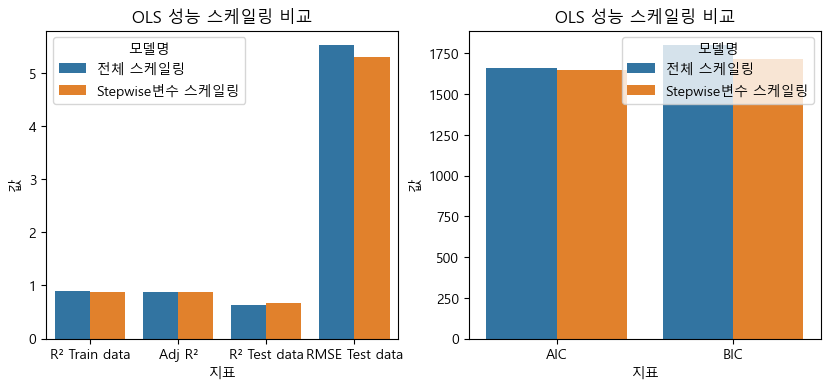

결과 출력
R² Train data     :    0.892 →    0.879 (↓ 감소, dif=-0.013)
Adj R²            :    0.878 →    0.873 (↓ 감소, dif=-0.005)
R² Test data      :    0.638 →    0.667 (↑ 향상, dif=0.029)
RMSE Test data    :    5.522 →    5.296 (↓ 감소, dif=-0.226)
AIC               : 1658.305 → 1651.363 (↓ 감소, dif=-6.942)
BIC               : 1800.903 → 1715.157 (↓ 감소, dif=-85.746)
- R², Adj R² 값이 높을수록 모델 좋음
- RMSE, AIC, BIC 값이 낮을수록 성능 좋음


In [18]:
results = {
    "모델명": ["전체 스케일링", "Stepwise변수 스케일링"],
    "R² Train data": [ols_scaled.rsquared, ols_stepwise_scaled.rsquared],
    "Adj R²": [ols_scaled.rsquared_adj, ols_stepwise_scaled.rsquared_adj],
    "R² Test data" : [r2_ols_scaled, r2_ols_stepwise_scaled],
    "RMSE Test data": [rmse_ols_scaled, rmse_ols_stepwise_scaled],
    "AIC": [ols_scaled.aic, ols_stepwise_scaled.aic],
    "BIC": [ols_scaled.bic, ols_stepwise_scaled.bic],
}
compare_df = pd.DataFrame(results)
plot1 = compare_df.melt(id_vars="모델명",
                        value_vars=["R² Train data", "Adj R²", "R² Test data", "RMSE Test data"],
                        var_name="지표", value_name="값")

plot2 = compare_df.melt(id_vars="모델명",
                        value_vars=["AIC", "BIC"],
                        var_name="지표", value_name="값")

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.barplot(data=plot1, x="지표", y="값", hue="모델명", ax=axes[0])
axes[0].set_title("OLS 성능 스케일링 비교")

sns.barplot(data=plot2, x="지표", y="값", hue="모델명", ax=axes[1])
axes[1].set_title("OLS 성능 스케일링 비교")
plt.show()

print("결과 출력")
for col in compare_df.columns[1:]:
    val1 = compare_df.loc[0, col]
    val2 = compare_df.loc[1, col]
    diff = val2 - val1
    trend = "↑ 향상" if diff > 0 else "↓ 감소" if diff < 0 else "-"
    print(f"{col:<18}: {val1:>8.3f} → {val2:>8.3f} ({trend}, dif={diff:.3f})")

print("- R², Adj R² 값이 높을수록 모델 좋음")
print("- RMSE, AIC, BIC 값이 낮을수록 성능 좋음")

# 3-2. 규제 기법

#  Ridge, Lasso, ElasticNet 적용 (임의의 하이퍼파라미터)

In [19]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet

# 규제 모델 정의
# Stepwise 진행한 데이터에 규제모델 진행
ridge = Ridge(alpha=1.0, max_iter=10000).fit(x_train_all[selected_features], y_train)          # Ridge L2 규제
lasso = Lasso(alpha=0.1, max_iter=10000).fit(x_train_all[selected_features], y_train)          # Lasso L1 규제
enet  = ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000).fit(x_train_all[selected_features], y_train)   # ElasticNet

# 성능 출력
def report(model, name):
    y_pred = model.predict(x_test_all[selected_features])
    rmse = np.sqrt(np.mean((y_test - y_pred)**2))
    r2 = 1 - np.sum((y_test - y_pred)**2) / np.sum((y_test - y_test.mean())**2)
    print(f"[{name}]")
    print(f"RMSE: {rmse:.4f}")
    print(f"R²  : {r2:.4f}")

# 각 규제 모델에 맞게 RMSE 와 R2를 출력확인
report(ridge, "Ridge")                  
report(lasso, "Lasso")
report(enet, "ElasticNet")

# 계수 비교
coef_df = pd.DataFrame({
    "feature": x_test_all[selected_features].columns,
    "ridge": ridge.coef_,
    "lasso": lasso.coef_,
    "elasticnet": enet.coef_
})
print("\n[계수 비교]")
print(coef_df.to_string(index=False))


[Ridge]
RMSE: 5.4417
R²  : 0.6489
[Lasso]
RMSE: 5.6446
R²  : 0.6222
[ElasticNet]
RMSE: 5.7257
R²  : 0.6113

[계수 비교]
    feature      ridge     lasso  elasticnet
        DIS  -1.031168 -0.832769   -0.807162
        TAX  -0.011729 -0.028398   -0.028715
    PTRATIO  -0.795031 -0.784620   -0.845777
    NOX_std  -1.705993 -1.101378   -1.305682
     RM_std -11.068019 -4.145672   -1.634806
    RAD_std   1.251608  0.000000    0.183108
     ZN_log   0.076430  0.000000   -0.000000
    TAX_log  -1.895965 -0.000000   -0.000000
PTRATIO_log  -0.648729 -0.000000   -0.000000
  LSTAT_log  -7.602470 -7.487738   -5.353005
    CRIM_mm  -7.769985 -0.000000   -0.633969
      ZN_mm  -2.026006 -0.000000   -0.000000
       B_mm   2.795208  1.455870    1.547595
      ZN_sq   0.000438  0.000223    0.000277
      RM_sq   1.492830  0.758369    0.549540
     TAX_sq   0.000008  0.000024    0.000022


# 4. Grid Search 최적 파라미터

In [20]:
# Grid Search와 CV를 통해 하이퍼파라미터를 탐색

from sklearn.model_selection import GridSearchCV

# Ridge, Lasso, ElasticNet의 하이퍼파라미터를 알맞게 조정
# alpha, l1_ratio

alphas = np.logspace(-3, 2, 20)                         # 0.001 ~ 100

# Ridge, Lasso, ElasticNet 모델과 파라미터
ridge_grid = {"alpha":  np.logspace(-6, 6, 100)}     # 1e-6 ~ 1e6 릿지
lasso_grid = {"alpha":  np.logspace(-6, 6, 100)}     # 1e-6 ~ 1e6 라쏘
enet_grid  = {
    "alpha":   np.logspace(-6, 6, 100),              # 1e-6 ~ 1e6 엘라스틱넷
    "l1_ratio":[0.2, 0.5, 0.8, 0.95, 1.0]
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)   # FKold cv 사용해 반복 확인

# GridSearchCV 각각 실행
# GridSearchCV는 KFold교차 검증 평균으로 측정하며 최적 파라미터를 선택함
ridge = GridSearchCV(Ridge(), ridge_grid, cv=5)
lasso = GridSearchCV(Lasso(), lasso_grid, cv=5)
enet  = GridSearchCV(ElasticNet(), enet_grid, cv=5)

ridge.fit(x_train_all[selected_features], y_train)
lasso.fit(x_train_all[selected_features], y_train)
enet.fit(x_train_all[selected_features], y_train)

# 결과 출력
print("Best Ridge:", ridge.best_params_, "Score:", ridge.best_score_)
print("Best Lasso:", lasso.best_params_, "Score:", lasso.best_score_)
print("Best ElasticNet:", enet.best_params_, "Score:", enet.best_score_)

# 최적 모델로 Test 평가
best_models = {
    "Ridge": ridge.best_estimator_,
    "Lasso": lasso.best_estimator_,
    "ElasticNet": enet.best_estimator_
}

# 모델들의 최적의 파라미터에 맞는 결과 출력
for name, model in best_models.items():
    y_pred = model.predict(x_test_all[selected_features])
    rmse = np.sqrt(np.mean((y_test - y_pred)**2))
    r2 = 1 - np.sum((y_test - y_pred)**2) / np.sum((y_test - y_test.mean())**2)
    print(f"{name} Test RMSE: {rmse:.3f}")
    print(f"{name} Test R2: {r2:.3f}")

c:\Users\a6742\anaconda3\envs\BigDataClass\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.373e+03, tolerance: 2.002e+00
  model = cd_fast.enet_coordinate_descent(
c:\Users\a6742\anaconda3\envs\BigDataClass\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.366e+03, tolerance: 2.197e+00
  model = cd_fast.enet_coordinate_descent(
c:\Users\a6742\anaconda3\envs\BigDataClass\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider incre

Best Ridge: {'alpha': np.float64(0.0024770763559917113)} Score: 0.859222022212402
Best Lasso: {'alpha': np.float64(0.0014174741629268048)} Score: 0.8533257733970547
Best ElasticNet: {'alpha': np.float64(0.00011497569953977356), 'l1_ratio': 0.2} Score: 0.8539993438397447
Ridge Test RMSE: 5.303
Ridge Test R2: 0.667
Lasso Test RMSE: 5.368
Lasso Test R2: 0.658
ElasticNet Test RMSE: 5.363
ElasticNet Test R2: 0.659


c:\Users\a6742\anaconda3\envs\BigDataClass\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.645e+03, tolerance: 2.598e+00
  model = cd_fast.enet_coordinate_descent(


In [21]:
# 위에서 결정된 최적의 파라미터 적용
ridge_best_alpha = ridge.best_params_['alpha']
lasso_best_alpha = lasso.best_params_['alpha']
enet_best_alpha = enet.best_params_['alpha']
enet_best_l1 = enet.best_params_['l1_ratio']

print("\n최적 하이퍼파라미터")
print(f"Ridge alpha: {ridge_best_alpha}")
print(f"Lasso alpha: {lasso_best_alpha}")
print(f"ElasticNet alpha: {enet_best_alpha}, l1_ratio: {enet_best_l1}")

# 최적 파라미터 기반 모델 재학습 
ridge_final = Ridge(alpha=ridge_best_alpha).fit(x_train_all[selected_features], y_train)
lasso_final = Lasso(alpha=lasso_best_alpha).fit(x_train_all[selected_features], y_train)
enet_final  = ElasticNet(alpha=enet_best_alpha, l1_ratio=enet_best_l1).fit(x_train_all[selected_features], y_train)

# 성능 출력
def report(model, name):
    y_pred = model.predict(x_test_all[selected_features])
    rmse = np.sqrt(np.mean((y_test - y_pred)**2))
    r2 = 1 - np.sum((y_test - y_pred)**2) / np.sum((y_test - y_test.mean())**2)
    print(f"[{name}]")
    print(f"RMSE: {rmse:.4f}")
    print(f"R²  : {r2:.4f}")

report(ridge, "Ridge")
report(lasso, "Lasso")
report(enet, "ElasticNet")

# 계수 비교
coef_df = pd.DataFrame({
    "feature": x_test_all[selected_features].columns,
    "ridge": ridge_final.coef_,
    "lasso": lasso_final.coef_,
    "elasticnet": enet_final.coef_
})
print("\n[계수 비교]")
print(coef_df.to_string(index=False))


최적 하이퍼파라미터
Ridge alpha: 0.0024770763559917113
Lasso alpha: 0.0014174741629268048
ElasticNet alpha: 0.00011497569953977356, l1_ratio: 0.2
[Ridge]
RMSE: 5.3033
R²  : 0.6665
[Lasso]
RMSE: 5.3681
R²  : 0.6584
[ElasticNet]
RMSE: 5.3632
R²  : 0.6590

[계수 비교]
    feature      ridge      lasso  elasticnet
        DIS  -0.966245  -1.059443   -1.057120
        TAX   0.322214   0.017452    0.024028
    PTRATIO   1.509412  -0.337291   -0.169564
    NOX_std  -2.133928  -1.864489   -1.882909
     RM_std -14.441479 -14.107404  -14.058212
    RAD_std   1.362784   1.350373    1.352077
     ZN_log   1.486385   1.241550    1.182688
    TAX_log -64.260463  -7.526617   -8.899531
PTRATIO_log -42.974388  -8.723210  -11.906843
  LSTAT_log  -7.909063  -7.831294   -7.830880
    CRIM_mm -11.080216 -10.959014  -11.012736
      ZN_mm -23.842122 -20.201263  -19.324686
       B_mm   2.628102   2.563569    2.592926
      ZN_sq   0.002021   0.001852    0.001779
      RM_sq   1.846368   1.812131    1.806409
     TAX_s

c:\Users\a6742\anaconda3\envs\BigDataClass\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.665e+03, tolerance: 2.598e+00
  model = cd_fast.enet_coordinate_descent(
c:\Users\a6742\anaconda3\envs\BigDataClass\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.645e+03, tolerance: 2.598e+00
  model = cd_fast.enet_coordinate_descent(


# 5. 선별된 속성 스케일링

In [22]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import statsmodels.api as sm

# 데이터
df3 = df.copy().dropna().reset_index(drop=True)

# 로그 변환 CRIM LSTAT DIS
for col in ["CRIM", "LSTAT", "DIS"]:
    df3[f"{col}_log"] = np.log1p(df3[col].clip(lower=0))


# Min-Max 정규화 ZN
for col in ["ZN"]:
    df3[f"{col}_mm"] = (df3[col] - df3[col].min()) / (df3[col].max() - df3[col].min())

# 표준화 NOX RM TAX PTRATIO B
for col in ["NOX", "RM", "TAX", "PTRATIO", "B"]:
    std  = df3[col].std(ddof=0)
    df3[f"{col}_std"] = (df3[col] - df3[col].mean()) / std

features_mixed = [
    # 원본 변수
    "CRIM", "ZN", "CHAS", "NOX", "RM", "DIS", "RAD", "TAX", "PTRATIO", "B", "LSTAT",
    # 변환된 변수
    "CRIM_log", "LSTAT_log", "DIS_log",     # log
    "ZN_mm",         # Min-max
    "NOX_std", "RM_std", "TAX_std", "PTRATIO_std", "B_std"      # std
]

# 데이터 분리
x3 = df3[features_mixed]
y3 = df3["MEDV"]

x_train_new, x_test_new, y_train_new, y_test_new = train_test_split(
    x3, y3, test_size=0.2, random_state=42
)

x_train_sm_new = sm.add_constant(x_train_new)
x_test_sm_new = sm.add_constant(x_test_new)

model3 = sm.OLS(y_train_new, x_train_sm_new).fit()
print(model3.summary())

y_pred = model3.predict(x_test_sm_new)
rmse_new = np.sqrt(np.mean((y_test_new - y_pred) ** 2))
r2_new = 1 - np.sum((y_test_new - y_pred)**2) / np.sum((y_test_new - y_test_new.mean())**2)

print("\n 선별 스케일링 성능평가")
print(f"RMSE: {rmse_new:.4f}")
print(f"R²  : {r2_new:.4f}")

print(f"모델 사용 특성 수: {len(features_mixed)}")

                            OLS Regression Results                            
Dep. Variable:                   MEDV   R-squared:                       0.851
Model:                            OLS   Adj. R-squared:                  0.844
Method:                 Least Squares   F-statistic:                     122.0
Date:                Fri, 17 Oct 2025   Prob (F-statistic):          1.02e-114
Time:                        16:31:10   Log-Likelihood:                -842.54
No. Observations:                 315   AIC:                             1715.
Df Residuals:                     300   BIC:                             1771.
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.6275      0.043     14.637      

# 5-1. 선별된 스케일링 Stepwise

In [23]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)
base = LinearRegression()

best_k, best_score_f, best_selector = None, -np.inf, None

# 전진 선택법
for k in range(1, x_train_new.shape[1]):
    sfs_forward = SequentialFeatureSelector(
        base, n_features_to_select=k, direction="forward", scoring="r2", cv=cv)
    sfs_forward.fit(x_train_new, y_train_new)
    forward_cols = x_train_new.columns[sfs_forward.get_support()]
    score = cross_val_score(base, x_train_new[forward_cols], y_train_new, scoring="r2", cv=cv).mean()
    
    if score > best_score_f:
        best_k, best_score_f, best_selector = k, score, sfs_forward

best_forward = list(x_train_new.columns[best_selector.get_support()])
print("전진 선택법")
print("최적 k:", best_k)
print("CV R2:", round(best_score_f, 4))
print("선택된 컬럼:", list(x_train_new.columns[best_selector.get_support()]))

best_k, best_score_b, best_selector = None, -np.inf, None

# 후진 제거법
for k in range(1, x_train_new.shape[1]):
    sfs_backward = SequentialFeatureSelector(
        base, n_features_to_select=k, direction="backward", scoring="r2", cv=cv)
    sfs_backward.fit(x_train_new, y_train_new)
    backward_cols = x_train_new.columns[sfs_backward.get_support()]
    score = cross_val_score(base, x_train_new[backward_cols], y_train_new, scoring="r2", cv=cv).mean()
    
    if score > best_score_b:
        best_k, best_score_b, best_selector = k, score, sfs_backward

print("최적 k:", best_k)
print("CV R2:", round(best_score_b, 4))
best_backward = list(x_train_new.columns[best_selector.get_support()])
print("선택된 컬럼:",best_backward)


if best_score_f >= best_score_b:
    selected_features = best_forward
else:
    selected_features = best_backward

전진 선택법
최적 k: 12
CV R2: 0.8179
선택된 컬럼: ['CRIM', 'NOX', 'RM', 'DIS', 'RAD', 'TAX', 'B', 'LSTAT', 'CRIM_log', 'LSTAT_log', 'DIS_log', 'PTRATIO_std']
최적 k: 11
CV R2: 0.8191
선택된 컬럼: ['CRIM', 'NOX', 'RAD', 'TAX', 'PTRATIO', 'LSTAT', 'CRIM_log', 'LSTAT_log', 'DIS_log', 'RM_std', 'B_std']


# Stepwise 변수 데이터의 성능 평가

In [24]:
# 위 Stepwise 결과 중 성능 높은 결과로 진행
X_train_sm2 = sm.add_constant(x_train_new[selected_features])
X_test_sm2 = sm.add_constant(x_test_new[selected_features])

ols_stepwise_scaled = sm.OLS(y_train_new, X_train_sm2).fit()
print(ols_stepwise_scaled.summary())

# 성능 평가
y_pred = ols_stepwise_scaled.predict(X_test_sm2)
rmse_ols_stepwise_scaled = np.sqrt(np.mean((y_test_new - y_pred)**2))
r2_ols_stepwise_scaled = 1 - np.sum((y_test_new - y_pred)**2) / np.sum((y_test_new - y_test_new.mean())**2)

print(f"RMSE: {rmse_ols_stepwise_scaled:.4f}")
print(f"R²  : {r2_ols_stepwise_scaled:.4f}")

                            OLS Regression Results                            
Dep. Variable:                   MEDV   R-squared:                       0.848
Model:                            OLS   Adj. R-squared:                  0.843
Method:                 Least Squares   F-statistic:                     154.1
Date:                Fri, 17 Oct 2025   Prob (F-statistic):          5.27e-117
Time:                        16:31:53   Log-Likelihood:                -844.89
No. Observations:                 315   AIC:                             1714.
Df Residuals:                     303   BIC:                             1759.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         90.2650      4.292     21.030      0.0

# 5-2. 선별된 스케일링 속성의 Grid Search 규제기법

In [25]:
# Ridge, Lasso, ElasticNet의 하이퍼파라미터
# alpha, l1_ratio

alphas = np.logspace(-3, 2, 20)                         # 0.001 ~ 100

# Ridge, Lasso, ElasticNet 모델과 파라미터
ridge_grid = {"alpha":  np.logspace(-6, 6, 100)}     # 1e-6 ~ 1e6 릿지
lasso_grid = {"alpha":  np.logspace(-6, 6, 100)}     # 1e-6 ~ 1e6 라쏘
enet_grid  = {
    "alpha":   np.logspace(-6, 6, 100),              # 1e-6 ~ 1e6 엘라스틱넷
    "l1_ratio":[0.2, 0.5, 0.8, 0.95, 1.0]
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)   

ridge = GridSearchCV(Ridge(), ridge_grid, cv=5)
lasso = GridSearchCV(Lasso(), lasso_grid, cv=5)
enet  = GridSearchCV(ElasticNet(), enet_grid, cv=5)

ridge.fit(x_train_new, y_train_new)
lasso.fit(x_train_new, y_train_new)
enet.fit(x_train_new, y_train_new)

# 결과 출력
print("Best Ridge:", ridge.best_params_, "Score:", ridge.best_score_)
print("Best Lasso:", lasso.best_params_, "Score:", lasso.best_score_)
print("Best ElasticNet:", enet.best_params_, "Score:", enet.best_score_)

# 최적 모델로 Test 평가
best_models = {
    "Ridge": ridge.best_estimator_,
    "Lasso": lasso.best_estimator_,
    "ElasticNet": enet.best_estimator_
}

# 모델들의 최적의 파라미터에 맞는 결과 출력
for name, model in best_models.items():
    y_pred = model.predict(x_test_new)
    rmse = np.sqrt(np.mean((y_test_new - y_pred)**2))
    r2 = 1 - np.sum((y_test_new - y_pred)**2) / np.sum((y_test_new - y_test_new.mean())**2)
    print(f"{name} Test RMSE: {rmse:.3f}")
    print(f"{name} Test R2: {r2:.3f}")

c:\Users\a6742\anaconda3\envs\BigDataClass\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.522e+03, tolerance: 2.002e+00
  model = cd_fast.enet_coordinate_descent(
c:\Users\a6742\anaconda3\envs\BigDataClass\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.595e+03, tolerance: 2.197e+00
  model = cd_fast.enet_coordinate_descent(
c:\Users\a6742\anaconda3\envs\BigDataClass\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider incre

Best Ridge: {'alpha': np.float64(0.16297508346206435)} Score: 0.8161567669980008
Best Lasso: {'alpha': np.float64(0.0008111308307896872)} Score: 0.8161203678070269
Best ElasticNet: {'alpha': np.float64(0.0008111308307896872), 'l1_ratio': 0.5} Score: 0.8161551237887299
Ridge Test RMSE: 5.459
Ridge Test R2: 0.647
Lasso Test RMSE: 5.455
Lasso Test R2: 0.647
ElasticNet Test RMSE: 5.460
ElasticNet Test R2: 0.647


c:\Users\a6742\anaconda3\envs\BigDataClass\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.956e+03, tolerance: 2.598e+00
  model = cd_fast.enet_coordinate_descent(
